# Optimización local: el problema de las 4 reinas

En este ejercicio modelaremos el problema de las **4 reinas** como un problema de optimización y construiremos tres algoritmos:

1. **Hill Climbing**
2. **Hill Climbing con Random Restart**
3. **Simulated Annealing**

La mayor parte de las funciones están incompletas. Deben implementarse durante la clase.

---

## Objetivo

Ubicar cuatro reinas en un tablero $4 \times 4$ de forma que ninguna pareja se ataque.

Una reina ataca a otra si ambas están:

- en la misma fila;
- en la misma columna;
- en la misma diagonal.

## 1. Formulación como problema de optimización

Representaremos un estado mediante un vector:

$$
x = [x_0, x_1, x_2, x_3]
$$

donde $x_i$ indica la **fila** de la reina ubicada en la columna $i$.

Por ejemplo:

$$
x = [1, 3, 0, 2]
$$

representa las posiciones:

$$
(1,0), (3,1), (0,2), (2,3)
$$

Como cada columna contiene exactamente una reina, no pueden existir conflictos por columna.

### Espacio de búsqueda

Cada una de las cuatro reinas puede estar en cualquiera de las cuatro filas:

$$
|\mathcal{X}| = 4^4 = 256
$$

### Función de costo

Definiremos:

$$
C(x) = \text{número de parejas de reinas que se atacan}
$$

El objetivo es resolver:

$$
\min_{x \in \mathcal{X}} C(x)
$$

Una solución válida satisface:

$$
C(x)=0
$$

In [ ]:
import math
import random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#F0D9B5", "#B58863"])



N = 8
SEED = 42
random.seed(SEED)

## 2. Visualización de un estado

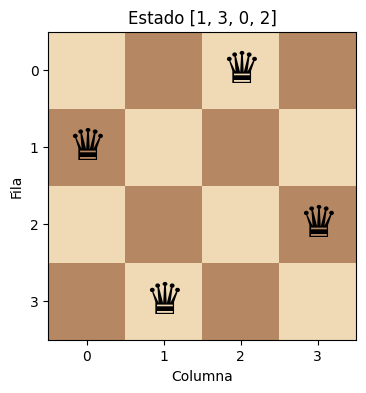

In [141]:
def plot_board(state, title=None):
    """Visualiza un estado del problema de las N reinas."""
    n = len(state)
    board = [[(row + col) % 2 for col in range(n)] for row in range(n)]

    plt.figure(figsize=(4, 4))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)

    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=32)

    plt.xticks(range(n))
    plt.yticks(range(n))
    plt.xlabel("Columna")
    plt.ylabel("Fila")
    plt.grid(False)
    if title:
        plt.title(title)

    plt.imshow(board, cmap=cmap)


example_state = [1, 3, 0, 2]
plot_board(example_state, title=f"Estado {example_state}")

## Actividad 1. Detectar conflictos

Dos reinas ubicadas en $(r_i,c_i)$ y $(r_j,c_j)$ se atacan si:

$$
r_i = r_j
$$

o si están en la misma diagonal:

$$
|r_i-r_j| = |c_i-c_j|
$$

Complete la función `attacking`.

In [142]:
def attacking(row_i, col_i, row_j, col_j):
    """Retorna True si dos reinas se atacan."""
    # TODO: misma fila o misma diagonal
    if (row_i == row_j) or (col_i == col_j) or (abs(row_i - row_j) == abs(col_i - col_j)):
        return True
    else :
        return False
            

In [143]:
# Pruebas de la actividad 1
assert attacking(0, 0, 0, 3) is True       # misma fila
assert attacking(0, 0, 3, 3) is True       # misma diagonal
assert attacking(0, 0, 1, 3) is False      # no se atacan

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 2. Función de costo

Implemente una función que cuente cuántas parejas de reinas se atacan.

Para cuatro reinas existen:

$$
\binom{4}{2}=6
$$

parejas posibles.

In [144]:
def cost(state):
    """Cuenta el número de parejas de reinas que se atacan."""
    num_attacks = 0
    n = len(state)
    
   
    for i in range(n):
        
        for j in range(i + 1, n):
            if attacking(state[i], i, state[j], j):
                num_attacks += 1
                
    return num_attacks

In [145]:
# Pruebas de la actividad 2
assert cost([0, 0, 0, 0]) == 6
assert cost([0, 1, 2, 3]) == 6
assert cost([1, 3, 0, 2]) == 0

print("Pruebas superadas.")

Pruebas superadas.


## 3. Vecindario

Un vecino se obtiene moviendo **una sola reina** a otra fila de su misma columna.

Para cada una de las $N$ columnas hay $N-1$ movimientos posibles:

$$
|N(x)| = N(N-1)
$$

Para $N=4$:

$$
|N(x)|=4(3)=12
$$

## Actividad 3. Generar los vecinos

Implemente `neighbors(state)`.

La función debe retornar todos los estados que difieren del original en la fila de exactamente una reina.

In [146]:
def neighbors(state):
    """Genera todos los estados vecinos moviendo una reina."""
    neighborhood = []
    n = len(state)
    
    
    for col in range(n):
        
        for row in range(n):
            if row != state[col]:
                new_state = state.copy()
                new_state[col] = row
                neighborhood.append(new_state)
                
    return neighborhood

In [147]:
# Pruebas de la actividad 3
test_state = [0, 1, 2, 3]
test_neighbors = neighbors(test_state)

assert len(test_neighbors) == 12
assert test_state not in test_neighbors
assert len({tuple(s) for s in test_neighbors}) == 12

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 4. Mejor vecino

Implemente una función que encuentre el menor costo entre todos los vecinos.

Cuando existan varios vecinos con el mismo costo mínimo, seleccione uno aleatoriamente.

In [148]:
def best_neighbor(state):
    all_neighbors = neighbors(state)
    
    evaluated_neighbors = [(n, cost(n)) for n in all_neighbors]
    
    min_cost = min(c for _, c in evaluated_neighbors)
    
    best_candidates = [n for n, c in evaluated_neighbors if c == min_cost]
    
    chosen_neighbor = random.choice(best_candidates)
    
  
    return chosen_neighbor, min_cost

In [149]:
# Prueba básica
state = [0, 0, 0, 0]
next_state, next_cost = best_neighbor(state)

assert next_state in neighbors(state)
assert next_cost == cost(next_state)
assert next_cost == min(cost(s) for s in neighbors(state))

print("Pruebas superadas.")

Pruebas superadas.


## 4. Hill Climbing

Hill Climbing comienza en un estado inicial y se mueve repetidamente hacia un vecino con menor costo.

$$
x_{t+1} = \arg\min_{y \in N(x_t)} C(y)
$$

El algoritmo termina cuando:

- encuentra una solución con costo cero; o
- ningún vecino mejora el estado actual.

Este segundo caso puede corresponder a un **mínimo local** o a una **meseta**.

## Actividad 5. Implementar Hill Climbing

In [150]:
def hill_climbing(initial_state, max_steps=100):
    
    current_state = initial_state.copy()
    current_cost = cost(current_state)
    
    history = [current_state.copy()]
    
    for _ in range(max_steps):
        next_state, next_cost = best_neighbor(current_state)
        
        if next_cost >= current_cost:
            break
            
        current_state = next_state
        current_cost = next_cost
        history.append(current_state.copy())
        
    return current_state, history


Estado inicial: [0, 0, 0, 0]
Estado final: [1, 3, 0, 2]
Costo final: 0
Número de movimientos: 3


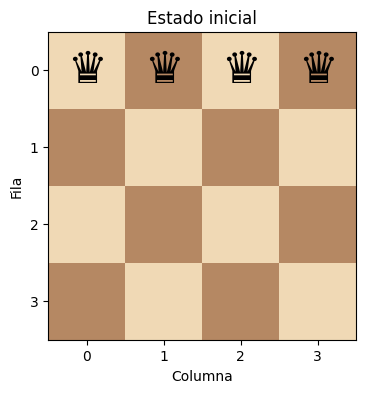

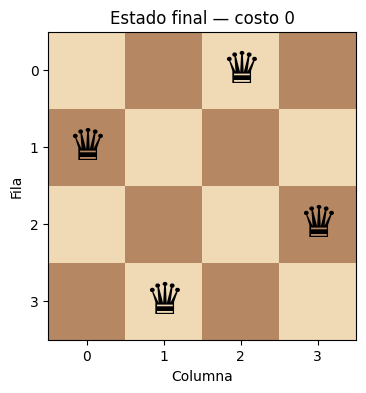

In [151]:
initial_state = [0, 0, 0, 0]
final_state, history = hill_climbing(initial_state)

print("Estado inicial:", initial_state)
print("Estado final:", final_state)
print("Costo final:", cost(final_state))
print("Número de movimientos:", len(history) - 1)

plot_board(initial_state, "Estado inicial")
plot_board(final_state, f"Estado final — costo {cost(final_state)}")

## Actividad 6. Analizar una ejecución

Grafique el costo de los estados visitados por Hill Climbing.

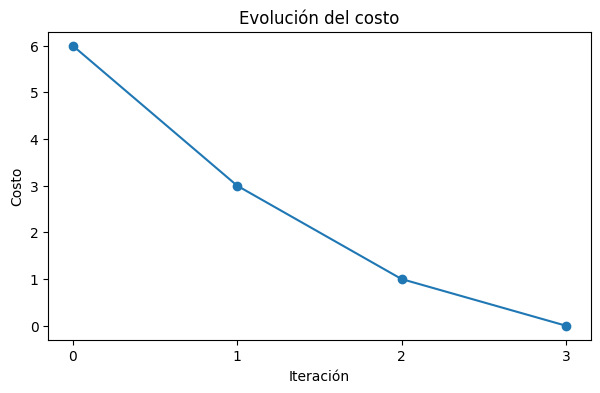

In [152]:
def plot_cost_history(history, title="Evolución del costo"):
    costs = [cost(state) for state in history]

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(costs)), costs, marker="o")
    plt.xlabel("Iteración")
    plt.ylabel("Costo")
    plt.title(title)
    plt.xticks(range(len(costs)))
    plt.show()


plot_cost_history(history)

## 5. Hill Climbing con Random Restart

Hill Climbing puede quedar atrapado en mínimos locales.

Random Restart ejecuta Hill Climbing desde diferentes estados iniciales:

$$
x_0^{(1)}, x_0^{(2)}, \ldots, x_0^{(R)}
$$

El algoritmo termina cuando encuentra una solución o cuando agota el número máximo de reinicios.

## Actividad 7. Implementar Random Restart

In [153]:
def random_state(n=N):
    """Genera un estado aleatorio."""
    return [random.randrange(n) for _ in range(n)]


def random_restart_hill_climbing(max_restarts=50, max_steps=100):
    """
    Ejecuta Hill Climbing desde varios estados iniciales.

    Retorna:
        best_state: mejor estado encontrado
        best_history: trayectoria de la mejor ejecución
        restarts_used: número de reinicios realizados
    """
    best_state = None
    best_history = None
    best_cost = math.inf
    
    for restart in range(1, max_restarts + 1):
        initial_state = random_state()
        final_state, history = hill_climbing(initial_state, max_steps=max_steps)
        final_cost = cost(final_state)

        if final_cost < best_cost:
            best_state = final_state
            best_history = history
            best_cost = final_cost

        if best_cost == 0:
            return best_state, best_history, restart

    return best_state, best_history, max_restarts

Mejor estado: [2, 0, 3, 1]
Costo: 0
Reinicios utilizados: 4


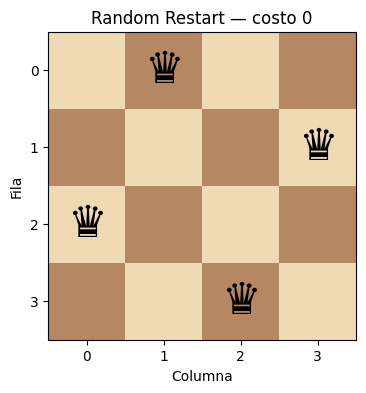

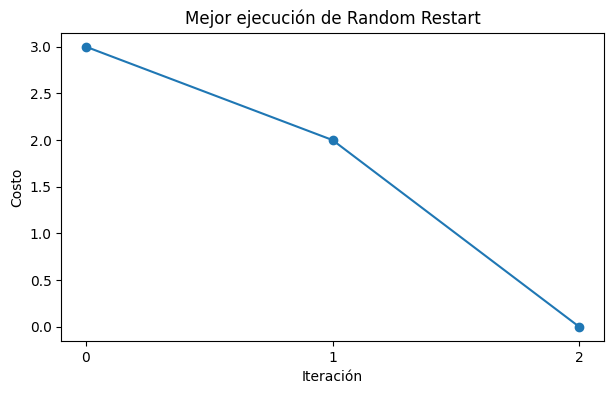

In [154]:
best_state, best_history, restarts = random_restart_hill_climbing()

print("Mejor estado:", best_state)
print("Costo:", cost(best_state))
print("Reinicios utilizados:", restarts)

plot_board(best_state, f"Random Restart — costo {cost(best_state)}")
plot_cost_history(best_history, "Mejor ejecución de Random Restart")

## 6. Simulated Annealing

Simulated Annealing permite aceptar temporalmente movimientos que empeoran la solución.

Si un vecino tiene costo menor o igual, se acepta.

Si empeora el costo en una cantidad:

$$
\Delta C = C(x') - C(x) > 0
$$

se acepta con probabilidad:

$$
P(\text{aceptar}) = e^{-\Delta C/T}
$$

donde $T$ es la temperatura.

Usaremos un enfriamiento geométrico:

$$
T_{t+1} = \alpha T_t
$$

con $0 < \alpha < 1$.

## Actividad 8. Probabilidad de aceptación

In [155]:
def acceptance_probability(current_cost, candidate_cost, temperature):
    """Calcula la probabilidad de aceptar un estado candidato."""
    delta_cost = candidate_cost - current_cost
    if delta_cost < 0:
        return 1.0
    else:
        return math.exp(-delta_cost / temperature)

In [156]:
assert acceptance_probability(3, 2, 1.0) == 1.0
assert acceptance_probability(3, 3, 1.0) == 1.0

p = acceptance_probability(2, 3, 1.0)
assert math.isclose(p, math.exp(-1), rel_tol=1e-9)

print("Pruebas superadas.")

Pruebas superadas.


## Actividad 9. Implementar Simulated Annealing

En cada iteración:

1. seleccione un vecino aleatorio;
2. calcule el cambio de costo;
3. acepte siempre las mejoras;
4. acepte algunos movimientos peores según la temperatura;
5. reduzca la temperatura.

In [157]:
def simulated_annealing(
    initial_state,
    initial_temperature=10.0,
    cooling_rate=0.95,
    min_temperature=1e-3,
    max_steps=1000,
):
    """
    Ejecuta Simulated Annealing.

    Retorna:
        best_state: mejor estado encontrado
        history: estados aceptados durante la búsqueda
        temperatures: temperatura asociada a cada estado
    """
    current_state = initial_state.copy()
    current_cost = cost(current_state)
    
    best_state = current_state.copy()
    best_cost = current_cost

    temperature = initial_temperature

    history = [current_state.copy()]
    temperatures = [temperature]
    
    for _ in range(max_steps):
        if current_cost == 0 or temperature < min_temperature:
            break

        candidate = random.choice(neighbors(current_state))
        candidate_cost = cost(candidate)

        p = acceptance_probability(current_cost, candidate_cost, temperature)

        if random.random() < p:
            current_state = candidate
            current_cost = candidate_cost
            history.append(current_state.copy())
            temperatures.append(temperature)

            if current_cost < best_cost:
                best_state = current_state.copy()
                best_cost = current_cost

        temperature *= cooling_rate

    return best_state, history, temperatures

Estado inicial: [3, 0, 2, 2]
Mejor estado: [2, 0, 3, 1]
Costo final: 0
Estados aceptados: 53


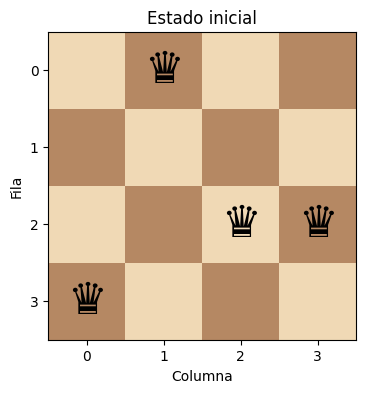

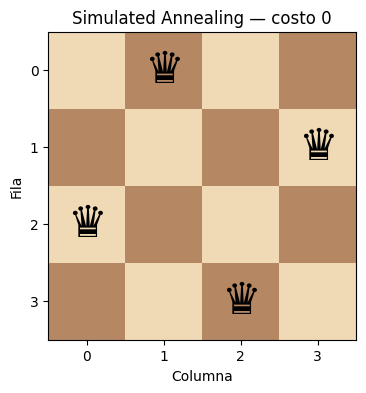

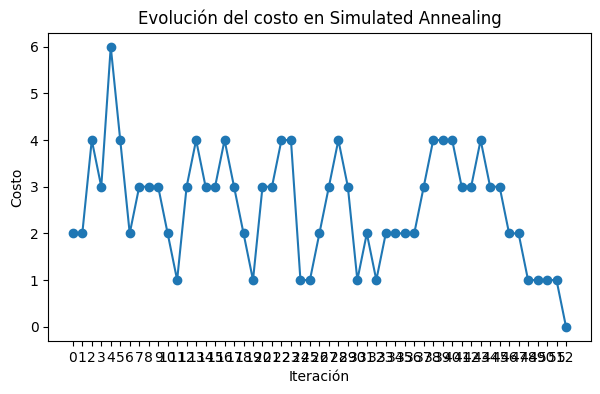

In [158]:
initial_state = random_state()
sa_state, sa_history, temperatures = simulated_annealing(initial_state)

print("Estado inicial:", initial_state)
print("Mejor estado:", sa_state)
print("Costo final:", cost(sa_state))
print("Estados aceptados:", len(sa_history))

plot_board(initial_state, "Estado inicial")
plot_board(sa_state, f"Simulated Annealing — costo {cost(sa_state)}")
plot_cost_history(sa_history, "Evolución del costo en Simulated Annealing")

## Actividad 10. Comparación experimental

Ejecute cada algoritmo varias veces y registre su tasa de éxito.

Una ejecución es exitosa cuando encuentra un estado con costo cero.

In [159]:
def compare_algorithms(trials=100):
    results = {
        "Hill Climbing": 0,
        "Random Restart": 0,
        "Simulated Annealing": 0,
    }

    for _ in range(trials):
        initial_state = random_state()

        hc_state, _ = hill_climbing(initial_state)
        if cost(hc_state) == 0:
            results["Hill Climbing"] += 1

        rr_state, _, _ = random_restart_hill_climbing(max_restarts=20)
        if cost(rr_state) == 0:
            results["Random Restart"] += 1

        sa_state, _, _ = simulated_annealing(initial_state)
        if cost(sa_state) == 0:
            results["Simulated Annealing"] += 1

    return results


# Descomente cuando haya terminado todas las implementaciones.
results = compare_algorithms(trials=100)
for algorithm, successes in results.items():
    print(f"{algorithm:20s}: {successes}/100")

Hill Climbing       : 36/100
Random Restart      : 100/100
Simulated Annealing : 98/100


## Preguntas de discusión

1. ¿Por qué Hill Climbing puede fallar aunque exista una solución? \
R/ Hill Climbing solo avanza cuando encuentra un vecino con costo estrictamente menor. En cuanto ningún vecino mejora el estado actual, el algoritmo se detiene, sin importar si esa detención ocurre en un mínimo local o en una meseta, y sin importar si existe una solución de costo 0 en otra parte del tablero. Para N=4, el espacio de búsqueda es pequeño (256 estados), por lo que estos mínimos locales y mesetas son relativamente fáciles de alcanzar desde un estado inicial aleatorio, de ahí la tasa de éxito baja (~35-45%).

2. ¿Qué diferencia existe entre una meseta y un mínimo local? \
R/ En una meseta los vecinos y el estado actual tienen el mismo costo, es decir, no es mejor ni es peor, esto provoca que Hill Climbing se detenga pues ningun vecino representa una mejora estricta. Un minimo local es un punto en donde todos los vecinos representan un mayor costo, empeorando el estado, pero esto no asegura que el estado actual sea el mas optimo, es literalmente el punto más bajo en su vecindario inmediato, puede existir otro mas bajo global, pero el algoritmo no tiene como llegar a el. En ambos casos el comportamiento del algoritmo es el mismo, simplemente detiene la ejecucion.

3. ¿Por qué Random Restart mejora la probabilidad de encontrar una solución? \
R/ Random Restart no garantiza evitar mínimos locales en cada intento individual, pero al ser reinicios independientes desde estados distintos, reduce drásticamente la probabilidad de que todos fallen a la vez, por lo tanto, si un intento falla, no afectaria el resultado del siguiente. Esto se comprueba matematicamente, pues si p es la probabilidad de que falle el intento actual, la posibilidad de que los n intentos fallen es de p^n, esto significa que a mas intentos (Como n=20), la posibilidad de que fallen todos los reinicios tiende a ser un numero extremadamente pequeño sin importar que p sea alto.

4. ¿Qué ocurre en Simulated Annealing cuando la temperatura es muy alta? \
R/ En los casos de que la temperatura sea muy alta (T &rarr; &infin;) el termino -$\Delta$ C/T tiende a 0, por lo tanto $e^{−\Delta C/T}$ se acerca a 1, lo que provoca que el algoritmo acepte cualquier movimiento incluso si este empeora el costo. Por lo tanto, Simulated Annealing tenga un comportamiento parecido a una busqueda aleatoria priorizando la exploracion del espacio de busqueda por encima de la explotación de soluciones ya conocidas.

5. ¿Qué ocurre si la temperatura disminuye demasiado rápido? \
R/ Si el `Cooling_rate` es muy bajo, la temperatura cae rapidamente hacia min_temperature, haciendo que el algoritmo cuente con pocas iteraciones para poder empeorar el costo, con un T muy bajo $e^{−ΔC/T}$ se acerca a 0 para cualquier $\Delta$ C > 0, por lo tanto el algoritmo casi nunca acepta empeorar la solucion. Si esto ocurriera antes de que el algoritmo tenga oportunidad de explorar lo suficiente, Simulate Annealing se comportaria como si fuera Hill Climbing, es decir, se quedaria atrapado en el primer minimo local o meseta que encuentra, perdiendo su capacidad optima de escapar de dichas situaciones.

6. ¿Cómo cambiaría el tamaño del espacio de búsqueda para 8 reinas? \
R/ Para N reinas, cada una de las N columnas puede ubicarse en cualquiera de las N filas, por lo que el espacio de búsqueda total es $N^N$. Para N = 4, son $4^4 = 256$ estados, mientras que para N = 8 serian $8^8 = 16,777,216$ estados. Demostrando un crecimiento exponencial , no lineal.
Tambien aumentaria el tamaño del vecindario, ya que $|N(x)| = N(N-1)$. Por eso, pasa de 12 vecinos cuando N=4 a 56 cuando N=8, por cada estado evaluado en cada paso de Hill Climbing o Simulated Annealing

7. ¿Cuál de los tres algoritmos fue más confiable en los experimentos? \
R/ En los experimentos, Random Restart fue el más confiable, con un éxito constante de 100/100 en cada ejecución. Simulated Annealing tuvo resultados muy similares (96-100/100), aunque con algo más de variabilidad al depender de una sola trayectoria. Hill Climbing simple fue el menos confiable (32-48/100), ya que no tiene un mecanismo para escapar de mínimos locales o mesetas.
Random Restart, sin embargo, tiene un mayor costo computacional, porque en el peor caso puede ejecutar Hill Climbing hasta 20 veces por prueba, mientras que Simulated Annealing realiza una sola ejecución más larga.


## Reto adicional

Modifique:

```python
N = 8
```

y evalúe los algoritmos en el problema de las **8 reinas**.

Compare:

- tasa de éxito;
- número de iteraciones;
- número de reinicios;
- sensibilidad a la temperatura inicial;
- sensibilidad a la tasa de enfriamiento.

// Para realizar este reto, se agregaran 4 celdas de codigo adicional para capturar los datos necesarios (measure_iterations, measure_restarts, sensitivity_temperature y sensitivity_cooling) //

In [160]:
def measure_iterations(n, trials=100):
    hc_iters, sa_iters = [], []
    for _ in range(trials):
        initial_state = random_state(n)
        _, hc_hist = hill_climbing(initial_state)
        hc_iters.append(len(hc_hist) - 1)
        _, sa_hist, _ = simulated_annealing(initial_state)
        sa_iters.append(len(sa_hist) - 1)
    return hc_iters, sa_iters

hc_iters, sa_iters = measure_iterations(N, trials=100)
print(f"Hill Climbing — iteraciones promedio: {sum(hc_iters)/len(hc_iters):.1f}")
print(f"Simulated Annealing — iteraciones promedio: {sum(sa_iters)/len(sa_iters):.1f}")

Hill Climbing — iteraciones promedio: 1.7
Simulated Annealing — iteraciones promedio: 37.5


In [161]:
def measure_restarts(n, trials=100, max_restarts=20):
    restarts_list = []
    for _ in range(trials):
        _, _, r = random_restart_hill_climbing(max_restarts=max_restarts)
        restarts_list.append(r)
    return restarts_list

restarts_n = measure_restarts(N, trials=100)
print(f"Reinicios promedio: {sum(restarts_n)/len(restarts_n):.1f}, máximo: {max(restarts_n)}")

Reinicios promedio: 2.3, máximo: 9


In [162]:
def sensitivity_temperature(n, temperatures, trials=100):
    results = {}
    for t in temperatures:
        successes = 0
        for _ in range(trials):
            state = random_state(n)
            final_state, _, _ = simulated_annealing(state, initial_temperature=t)
            if cost(final_state) == 0:
                successes += 1
        results[t] = successes
    return results

temp_results = sensitivity_temperature(N, temperatures=[1, 5, 10, 50, 100], trials=100)
for t, s in temp_results.items():
    print(f"T inicial={t:6.1f}: {s}/100 éxitos")

T inicial=   1.0: 96/100 éxitos
T inicial=   5.0: 99/100 éxitos
T inicial=  10.0: 100/100 éxitos
T inicial=  50.0: 99/100 éxitos
T inicial= 100.0: 99/100 éxitos


In [163]:
def sensitivity_cooling(n, rates, trials=100):
    results = {}
    for r in rates:
        successes = 0
        for _ in range(trials):
            state = random_state(n)
            final_state, _, _ = simulated_annealing(state, cooling_rate=r)
            if cost(final_state) == 0:
                successes += 1
        results[r] = successes
    return results

cooling_results = sensitivity_cooling(N, rates=[0.80, 0.90, 0.95, 0.99], trials=100)
for r, s in cooling_results.items():
    print(f"cooling_rate={r}: {s}/100 éxitos")

cooling_rate=0.8: 67/100 éxitos
cooling_rate=0.9: 85/100 éxitos
cooling_rate=0.95: 97/100 éxitos
cooling_rate=0.99: 100/100 éxitos


## Resultados

### N = 4, Trials = 100, Reinicios = 20

**Tasa de Éxito** \
Hill Climbing       : 36/100 \
Random Restart      : 100/100 \
Simulated Annealing : 98/100  

**Número de Iteraciones** \
Hill Climbing — iteraciones promedio: 1.7 \
Simulated Annealing — iteraciones promedio: 37.5 

**Número de Reinicios** \
Reinicios promedio: 2.3, máximo: 9 

**Sensibilidad a la temperatura inicial** \
T inicial=   1.0: 96/100 éxitos \
T inicial=   5.0: 99/100 éxitos \
T inicial=  10.0: 100/100 éxitos \
T inicial=  50.0: 99/100 éxitos \
T inicial= 100.0: 99/100 éxitos 

**Sensibilidad a la tasa de enfriamiento** \
cooling_rate=0.8: 67/100 éxitos \
cooling_rate=0.9: 85/100 éxitos \
cooling_rate=0.95: 97/100 éxitos \
cooling_rate=0.99: 100/100 éxitos 

### N = 8, Trials = 100, Reinicios = 20